In [ ]:
# ============================================================
# 0. Imports and configuration
# ============================================================
import os
from pathlib import Path
from collections import Counter
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as T
from torchvision.io import read_image
from torchvision.models import resnet18, ResNet18_Weights

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ---- PATHS ----
ID_ROOT = Path("/content/drive/MyDrive/AGST 892/Final Project/Dataset/sorted data/muzzle_id_optionA")

# ---- EXPERIMENT SETTINGS ----
MIN_IMAGES_PER_ID = 5      # keep only IDs with >= this many TRAIN images
batch_size = 32
num_workers = 2
num_epochs = 100
patience = 20
base_lr = 3e-4

# ---- REPRODUCIBILITY ----
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if device.type == "cuda":
    torch.cuda.manual_seed_all(seed)


Device: cuda


In [ ]:
# ============================================================
# 1. Scan folders and build filtered splits
# ============================================================

IMG_EXTS = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp")

def list_images(split_root: Path):
    """Return list of (path, cattle_id_str) for a split."""
    items = []
    for cid in sorted(os.listdir(split_root)):
        cdir = split_root / cid
        if not cdir.is_dir():
            continue
        for fname in os.listdir(cdir):
            if fname.lower().endswith(IMG_EXTS):
                items.append((cdir / fname, cid))
    return items

# 1.1 Count train images per ID
train_root = ID_ROOT / "train"
val_root   = ID_ROOT / "val"
test_root  = ID_ROOT / "test"

train_items_raw = list_images(train_root)
val_items_raw   = list_images(val_root)
test_items_raw  = list_images(test_root)

train_counts = Counter(cid for _, cid in train_items_raw)
print("Total TRAIN images:", len(train_items_raw))
print("Total IDs in TRAIN:", len(train_counts))

# 1.2 Select IDs with at least MIN_IMAGES_PER_ID in TRAIN
keep_ids = {cid for cid, n in train_counts.items() if n >= MIN_IMAGES_PER_ID}
print(f"Keeping {len(keep_ids)} IDs with >= {MIN_IMAGES_PER_ID} images in TRAIN")

# 1.3 Filter train/val/test items by these IDs
def filter_by_ids(items, keep_ids):
    return [(p, cid) for (p, cid) in items if cid in keep_ids]

train_items = filter_by_ids(train_items_raw, keep_ids)
val_items   = filter_by_ids(val_items_raw, keep_ids)
test_items  = filter_by_ids(test_items_raw, keep_ids)

print("Filtered TRAIN images:", len(train_items))
print("Filtered VAL images:", len(val_items))
print("Filtered TEST images:", len(test_items))

# 1.4 Build a consistent ID -> index mapping
all_ids = sorted(keep_ids)
id2idx = {cid: i for i, cid in enumerate(all_ids)}
idx2id = {i: cid for cid, i in id2idx.items()}
num_classes = len(all_ids)
print("num_classes:", num_classes)
print("First 20 IDs:", all_ids[:20])


Total TRAIN images: 2608
Total IDs in TRAIN: 207
Keeping 181 IDs with >= 5 images in TRAIN
Filtered TRAIN images: 2538
Filtered VAL images: 478
Filtered TEST images: 722
num_classes: 181
First 20 IDs: ['3802', '3812', '3813', '3814', '3832', '3844', '3847', '3852', '3856', '4323', '4326', '4330', '4339', '4347', '4363', '4369', '4381', '4385', '4421', '4422']


In [ ]:
# ============================================================
# 2. Transforms and custom dataset
# ============================================================

train_tfm = T.Compose([
    T.Resize((224, 224)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomApply([T.RandomRotation(degrees=15)], p=0.5),
    T.ColorJitter(brightness=0.3, contrast=0.3),
    T.RandomApply([T.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0))], p=0.3),
    T.ConvertImageDtype(torch.float32),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]),
])

test_tfm = T.Compose([
    T.Resize((224, 224)),
    T.ConvertImageDtype(torch.float32),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]),
])

class MuzzleIDDataset(Dataset):
    def __init__(self, items, id2idx, transform=None):
        """
        items: list of (img_path, cattle_id_str)
        id2idx: dict mapping cattle_id_str -> class index [0..num_classes-1]
        """
        self.items = items
        self.id2idx = id2idx
        self.transform = transform

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        img_path, cid = self.items[idx]
        img = read_image(str(img_path))  # [C,H,W] uint8
        if self.transform is not None:
            img = self.transform(img)
        label = self.id2idx[cid]
        return img, label

train_ds = MuzzleIDDataset(train_items, id2idx, transform=train_tfm)
val_ds   = MuzzleIDDataset(val_items,   id2idx, transform=test_tfm)
test_ds  = MuzzleIDDataset(test_items,  id2idx, transform=test_tfm)

print("== train ==")
print("num samples:", len(train_ds))
print("== val ==")
print("num samples:", len(val_ds))
print("== test ==")
print("num samples:", len(test_ds))


== train ==
num samples: 2538
== val ==
num samples: 478
== test ==
num samples: 722


In [ ]:
# ============================================================
# 3. Dataloaders (with class-balanced sampler for TRAIN)
# ============================================================

# Compute class frequency in train
train_labels = [lbl for _, lbl in train_ds]
class_counts = np.bincount(train_labels, minlength=num_classes)
class_weights = 1.0 / (class_counts + 1e-6)
sample_weights = class_weights[train_labels]
sampler = WeightedRandomSampler(sample_weights,
                                num_samples=len(sample_weights),
                                replacement=True)

train_loader = DataLoader(train_ds, batch_size=batch_size,
                          sampler=sampler, num_workers=num_workers)
val_loader   = DataLoader(val_ds,   batch_size=batch_size,
                          shuffle=False, num_workers=num_workers)
test_loader  = DataLoader(test_ds,  batch_size=batch_size,
                          shuffle=False, num_workers=num_workers)

# Quick sanity check
batch_imgs, batch_targets = next(iter(train_loader))
print("Batch images shape:", batch_imgs.shape)
print("Batch targets (first 10):", batch_targets[:10])
print("min target:", batch_targets.min().item(), "max target:", batch_targets.max().item())


Batch images shape: torch.Size([32, 3, 224, 224])
Batch targets (first 10): tensor([153,  33, 134,  58, 125,  90,  99,  97, 141,  77])
min target: 0 max target: 165


In [ ]:
# ============================================================
# 4. Define model (ResNet18 + AdamW)
# ============================================================

weights = ResNet18_Weights.IMAGENET1K_V1
backbone = resnet18(weights=weights)

# Replace final FC layer
num_features = backbone.fc.in_features
backbone.fc = nn.Linear(num_features, num_classes)

model = backbone.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=base_lr, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

print("Model ready. num_classes =", num_classes)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 209MB/s]

Model ready. num_classes = 181


In [ ]:
import pickle

# ============================================================
# 5. Training loop with early stopping
# ============================================================

def run_one_epoch(model, loader, optimizer=None):
    if optimizer is None:
        model.eval()
    else:
        model.train()

    total_loss = 0.0
    correct = 0
    total = 0

    for imgs, targets in loader:
        imgs = imgs.to(device)
        targets = targets.to(device)

        if optimizer is not None:
            optimizer.zero_grad()

        with torch.set_grad_enabled(optimizer is not None):
            logits = model(imgs)
            loss = criterion(logits, targets)

            if optimizer is not None:
                loss.backward()
                optimizer.step()

        total_loss += loss.item() * imgs.size(0)
        _, preds = torch.max(logits, dim=1)
        correct += (preds == targets).sum().item()
        total += imgs.size(0)

    avg_loss = total_loss / total
    acc = correct / total if total > 0 else 0.0
    return avg_loss, acc

history = {
    "train_loss": [],
    "train_acc":  [],
    "val_loss":   [],
    "val_acc":    []
}

best_val_loss = float("inf")
best_epoch = -1
best_model_path = ID_ROOT / "resnet18_muzzleID_best.pt"
history_path = ID_ROOT / "training_history.pkl" # Path to save history

for epoch in range(num_epochs):
    train_loss, train_acc = run_one_epoch(model, train_loader, optimizer)
    val_loss, val_acc     = run_one_epoch(model, val_loader, optimizer=None)

    scheduler.step()

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch+1:03d}/{num_epochs} | "
          f"train_loss={train_loss:.4f}, train_acc={train_acc:.3f} | "
          f"val_loss={val_loss:.4f}, val_acc={val_acc:.3f}")

    # Early stopping on val_loss
    if val_loss < best_val_loss - 1e-4:
        best_val_loss = val_loss
        best_epoch = epoch
        torch.save(model.state_dict(), best_model_path)
        # Save history along with the best model
        with open(history_path, "wb") as f:
            pickle.dump(history, f)
        print("   ✅ New best model and history saved!")
    elif epoch - best_epoch >= patience:
        print(f"   ⏹ Early stopping at epoch {epoch+1}")
        break

print("Best epoch:", best_epoch + 1, "best val_loss:", best_val_loss)
print("Best model path:", best_model_path)
print("Training history saved to:", history_path)

Epoch 001/100 | train_loss=2.7848, train_acc=0.583 | val_loss=0.9092, val_acc=0.891
   ✅ New best model and history saved!
Epoch 002/100 | train_loss=0.4207, train_acc=0.967 | val_loss=0.1674, val_acc=0.992
   ✅ New best model and history saved!
Epoch 003/100 | train_loss=0.0921, train_acc=0.997 | val_loss=0.0731, val_acc=0.992
   ✅ New best model and history saved!
Epoch 004/100 | train_loss=0.0656, train_acc=0.994 | val_loss=0.0447, val_acc=0.996
   ✅ New best model and history saved!
Epoch 005/100 | train_loss=0.0267, train_acc=1.000 | val_loss=0.0349, val_acc=0.996
   ✅ New best model and history saved!
Epoch 006/100 | train_loss=0.0193, train_acc=1.000 | val_loss=0.0288, val_acc=0.996
   ✅ New best model and history saved!
Epoch 007/100 | train_loss=0.0142, train_acc=1.000 | val_loss=0.0282, val_acc=0.996
   ✅ New best model and history saved!
Epoch 008/100 | train_loss=0.0126, train_acc=1.000 | val_loss=0.0269, val_acc=0.996
   ✅ New best model and history saved!
Epoch 009/100 | 

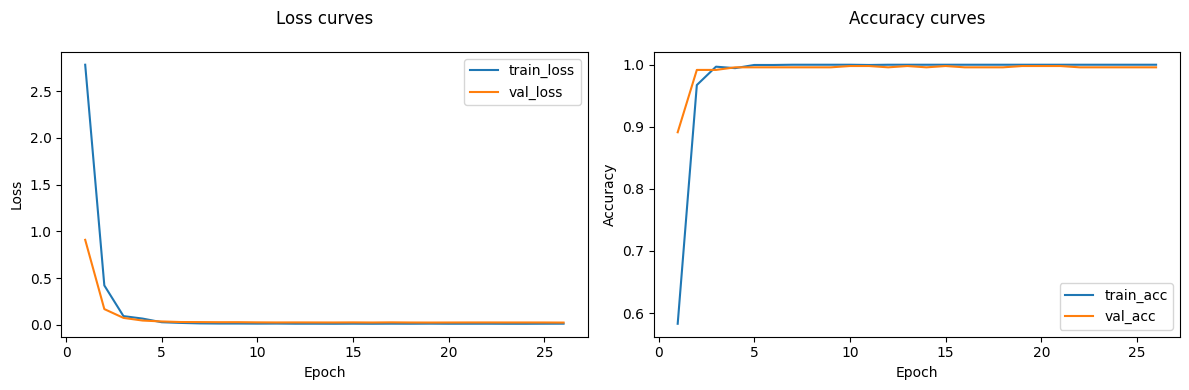

In [ ]:
# ============================================================
# 6. Plot training curves (loss & accuracy)
# ============================================================
import pickle

# Make sure history_path is defined
# And then load the history dictionary from the file
if 'history_path' not in locals():
    # Fallback if history_path was not defined by running AbCc9iUFVM1N
    # This assumes ID_ROOT is defined from cell 1RG0BOyYTG9g
    history_path = ID_ROOT / "training_history.pkl"

try:
    with open(history_path, "rb") as f:
        history = pickle.load(f)
except FileNotFoundError:
    print(f"Error: Training history file not found at {history_path}")
    print("Please ensure cell 5 (model training) has been run successfully to save the history.")
    raise

epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(epochs, history["train_loss"], label="train_loss")
plt.plot(epochs, history["val_loss"],   label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss curves", pad=20)
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs, history["train_acc"], label="train_acc")
plt.plot(epochs, history["val_acc"],   label="val_acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy curves", pad=20)
plt.legend()

plt.tight_layout()
plt.show()

Model loaded successfully from: /content/drive/MyDrive/AGST 892/Final Project/Dataset/sorted data/muzzle_id_optionA/resnet18_muzzleID_best.pt
Final (loaded best model):
  train_acc = 1.000, val_acc = 0.996, test_acc = 0.996


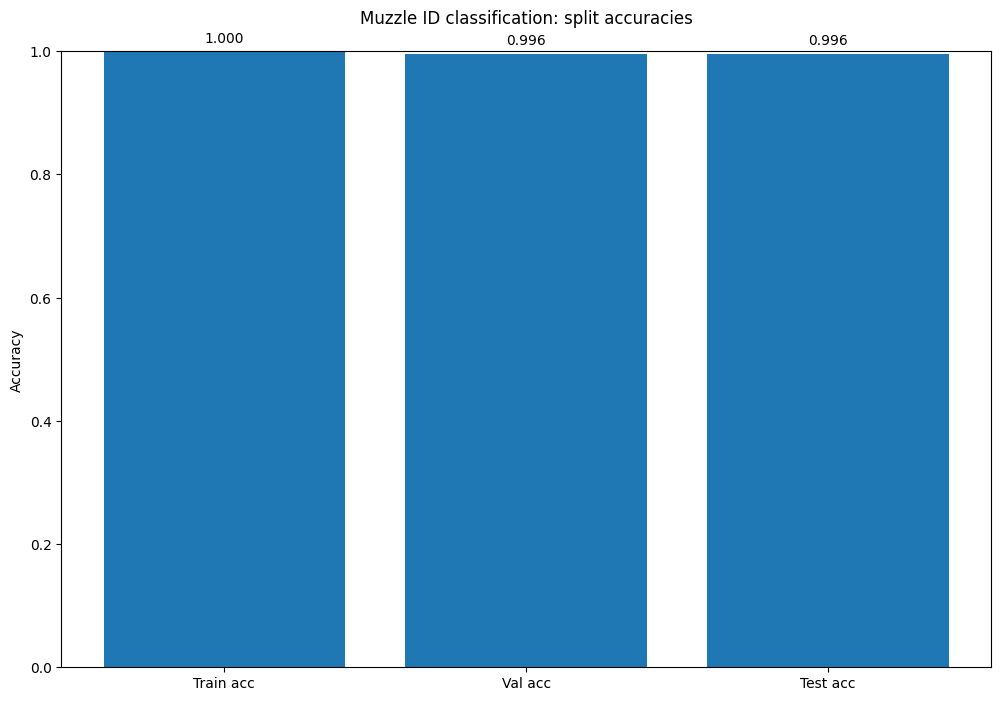

In [ ]:
# ============================================================
# 7. Evaluate best model on TEST set
# ============================================================
# Manually load the model architecture and saved weights
import torch
import torch.nn as nn
from torchvision.models import resnet18, ResNet18_Weights
best_model_path = ID_ROOT / "resnet18_muzzleID_best.pt"
# Ensure `device`, `num_classes`, and `best_model_path` are defined from previous cells.
# (e.g., from cells 1RG0BOyYTG9g, bhmWsyw2Tc7n, AbCc9iUFVM1N)

# Define the backbone (ResNet18) without pre-trained weights initially
# We are loading specific weights, so we don't need IMAGENET1K_V1 here.
# weights = ResNet18_Weights.IMAGENET1K_V1
backbone = resnet18(weights=None)

# Replace final FC layer to match the number of classes used during training
num_features = backbone.fc.in_features
backbone.fc = nn.Linear(num_features, num_classes)

# Move model to device
model = backbone.to(device)

# Load the best saved state_dict
model.load_state_dict(torch.load(best_model_path, map_location=device))

# Set model to evaluation mode
model.eval()

print("Model loaded successfully from:", best_model_path)
# Load best weights
model.load_state_dict(torch.load(best_model_path, map_location=device))

train_loss_final, train_acc_final = run_one_epoch(model, train_loader, optimizer=None)
val_loss_final,   val_acc_final   = run_one_epoch(model, val_loader,   optimizer=None)
test_loss_final,  test_acc_final  = run_one_epoch(model, test_loader,  optimizer=None)

print(f"Final (loaded best model):")
print(f"  train_acc = {train_acc_final:.3f}, val_acc = {val_acc_final:.3f}, test_acc = {test_acc_final:.3f}")

# Bar plot
metrics = ["Train acc", "Val acc", "Test acc"]
values  = [train_acc_final, val_acc_final, test_acc_final]

plt.figure(figsize=(12,8))
bars = plt.bar(metrics, values)
for b, v in zip(bars, values):
    plt.text(b.get_x() + b.get_width()/2, v + 0.01, f"{v:.3f}",
             ha="center", va="bottom", fontsize=10)
plt.ylim(0, 1.0)
plt.ylabel("Accuracy")
plt.title("Muzzle ID classification: split accuracies", pad=20)
plt.show()

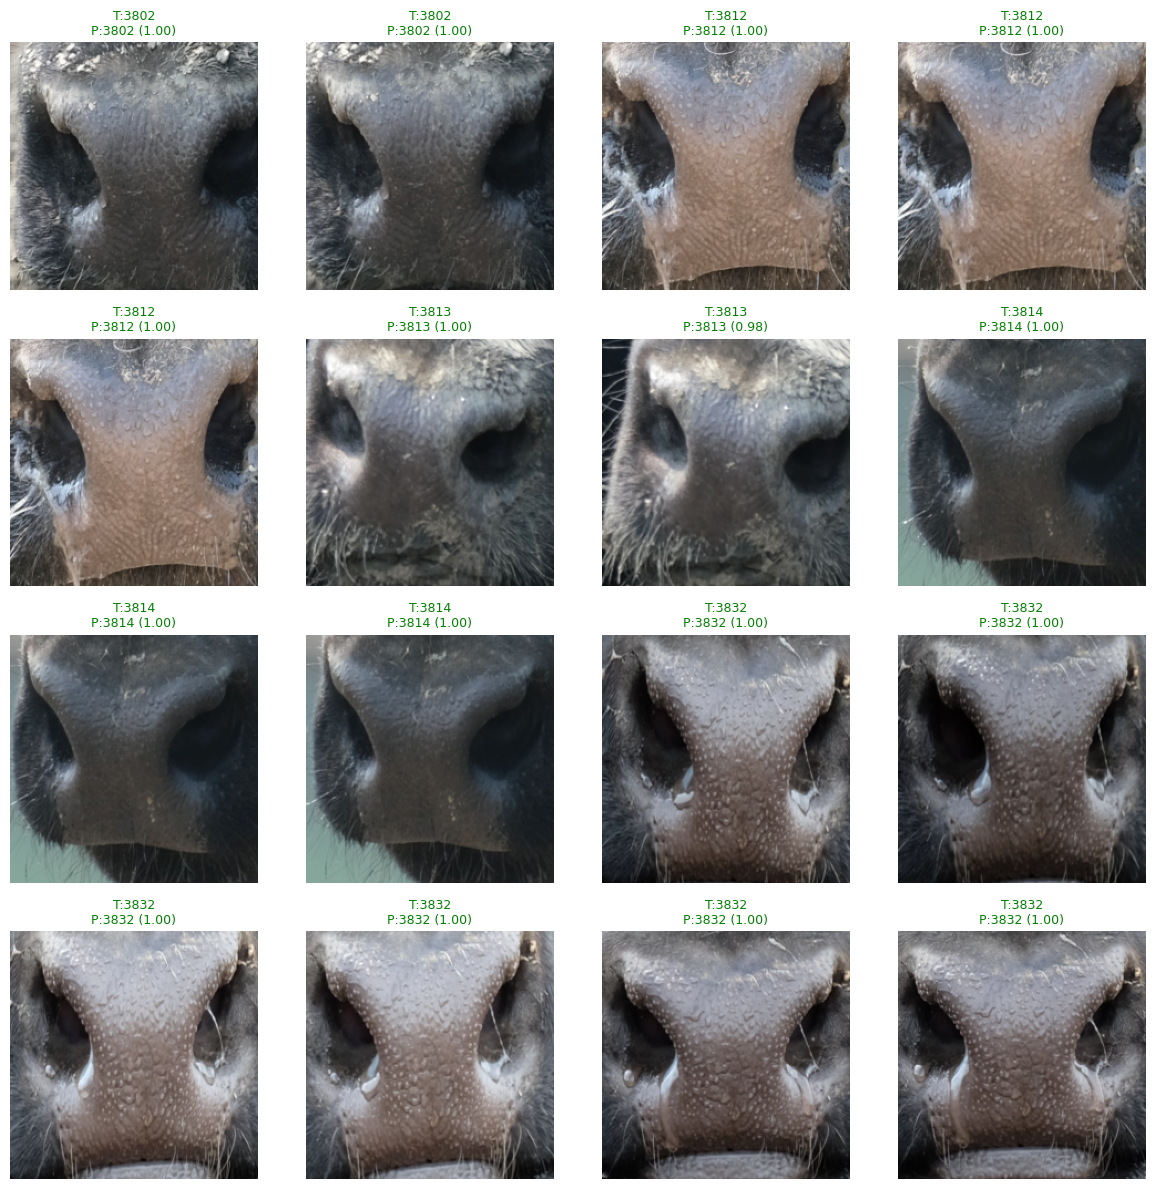

In [ ]:
# ============================================================
# 8. Visualise some TEST set predictions
# ============================================================
import torchvision.transforms.functional as F

# Helper: un-normalise for plotting
inv_mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1).to(device)
inv_std  = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1).to(device)

def unnormalize(imgs):
    # imgs: [B,3,H,W] normalized
    return imgs * inv_std + inv_mean

model.eval()

# Get one batch from the test loader
imgs, targets = next(iter(test_loader))
imgs = imgs.to(device)
targets = targets.to(device)

with torch.no_grad():
    logits = model(imgs)
    probs = torch.softmax(logits, dim=1)
    confs, preds = probs.max(dim=1)

# Move to CPU for plotting
imgs_vis = unnormalize(imgs).cpu().clamp(0, 1)
targets = targets.cpu()
preds   = preds.cpu()
confs   = confs.cpu()

# How many to show
n_show = min(16, imgs_vis.size(0))
n_cols = 4
n_rows = int(np.ceil(n_show / n_cols))

plt.figure(figsize=(3*n_cols, 3*n_rows))
for i in range(n_show):
    ax = plt.subplot(n_rows, n_cols, i+1)
    img = imgs_vis[i]
    img = F.to_pil_image(img)

    true_idx = targets[i].item()
    pred_idx = preds[i].item()
    conf     = confs[i].item()

    true_id = idx2id[true_idx]
    pred_id = idx2id[pred_idx]

    ax.imshow(img)
    ax.axis("off")

    # Green title if correct, red if wrong
    color = "green" if true_idx == pred_idx else "red"
    ax.set_title(f"T:{true_id}\nP:{pred_id} ({conf:.2f})",
                 color=color, fontsize=9)

plt.tight_layout()
plt.show()


In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 43.5 MB/s eta 0:00:00


In [ ]:
# === 1. Paths and muzzle class index ===
from ultralytics import YOLO
import cv2, glob, os, random
import matplotlib.pyplot as plt

# TODO: change these to your real paths
WEIGHTS_PATH = "/content/drive/MyDrive/AGST 892/Final Project/Dataset/sorted data/runs_optionA/y11n_cattle_ear_muzzle_adamw_aug3/weights/best.pt"
TEST_IMG_DIR = "/content/drive/MyDrive/AGST 892/Final Project/Dataset/sorted data/Yolo From json/optionA/test/images"

# IMPORTANT: muzzle class index in your YOLO dataset
#   - If your data.yaml has: names: [muzzle, ear-tag]  -> MUZZLE_ID = 0
#   - If it has: names: [cattle, muzzle, ear-tag]     -> MUZZLE_ID = 1
MUZZLE_ID = 2   # <-- change if needed

model = YOLO(WEIGHTS_PATH)
print("Loaded weights from:", WEIGHTS_PATH)


Loaded weights from: /content/drive/MyDrive/AGST 892/Final Project/Dataset/sorted data/runs_optionA/y11n_cattle_ear_muzzle_adamw_aug3/weights/best.pt


In [ ]:
import os

print("TEST_IMG_DIR =", TEST_IMG_DIR)
print("List test folder:", os.listdir(TEST_IMG_DIR)[:10])


TEST_IMG_DIR = /content/drive/MyDrive/AGST 892/Final Project/Dataset/sorted data/Yolo From json/optionA/test/images
List test folder: ['DSCF0131.JPG', 'DSCF0150.JPG', 'DSCF0157.JPG', 'DSCF0173.JPG', 'DSCF0179.JPG', 'DSCF0193.JPG', 'DSCF0199.JPG', 'DSCF0201.JPG', 'DSCF0202.JPG', 'DSCF0248.JPG']


In [ ]:
def show_image_with_muzzle_detections(img_path, conf_thres=0.25, imgsz=640):
    # read image
    img_bgr = cv2.imread(img_path)
    assert img_bgr is not None, f"Cannot read image: {img_path}"

    # run YOLO on this single image, restricted to muzzle class
    results = model(
        source=img_bgr,
        conf=conf_thres,
        imgsz=imgsz,
        classes=[MUZZLE_ID],   # only muzzle
        verbose=False
    )
    result = results[0]

    # draw YOLO's boxes/labels on the image
    annotated_bgr = result.plot(line_width=2, labels=True)

    # convert BGR -> RGB for matplotlib
    annotated_rgb = cv2.cvtColor(annotated_bgr, cv2.COLOR_BGR2RGB)

    # show
    plt.figure(figsize=(6, 6))
    plt.imshow(annotated_rgb)
    plt.axis("off")
    plt.title(os.path.basename(img_path))
    plt.show()


Found 362 test images

image 1/1 /content/drive/MyDrive/AGST 892/Final Project/Dataset/sorted data/Yolo From json/optionA/test/images/DSCF9056.JPG: 448x640 2 cattles, 2 ear-tags, 2 muzzles, 49.1ms
Speed: 12.4ms preprocess, 49.1ms inference, 6.3ms postprocess per image at shape (1, 3, 448, 640)


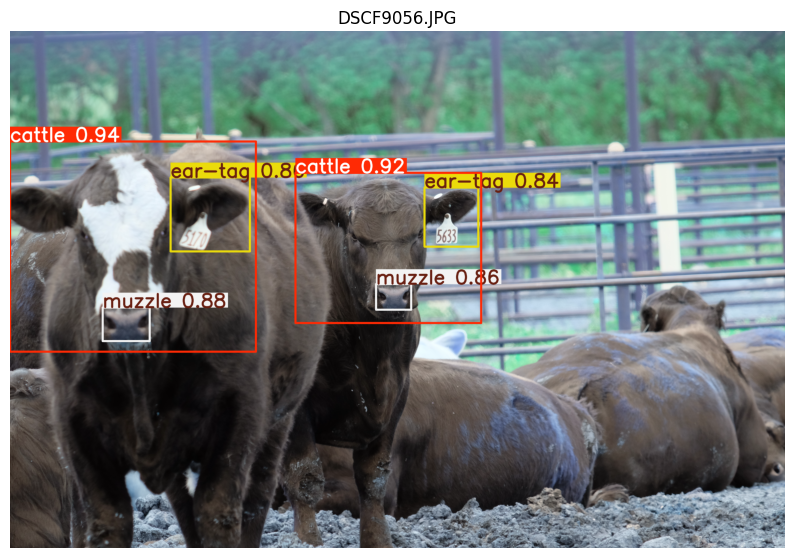


image 1/1 /content/drive/MyDrive/AGST 892/Final Project/Dataset/sorted data/Yolo From json/optionA/test/images/DSCF0645.JPG: 448x640 1 cattle, 1 ear-tag, 1 muzzle, 8.4ms
Speed: 2.7ms preprocess, 8.4ms inference, 1.5ms postprocess per image at shape (1, 3, 448, 640)


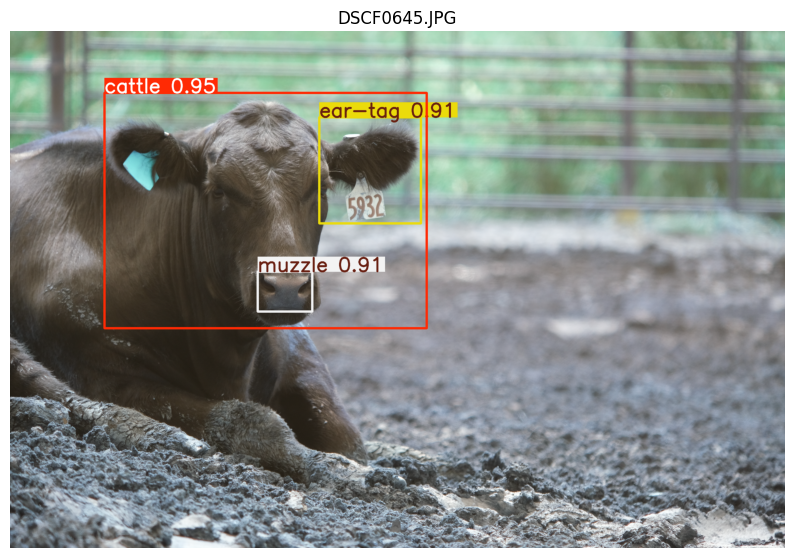


image 1/1 /content/drive/MyDrive/AGST 892/Final Project/Dataset/sorted data/Yolo From json/optionA/test/images/DSCF0278.JPG: 448x640 1 cattle, 1 ear-tag, 1 muzzle, 8.1ms
Speed: 2.7ms preprocess, 8.1ms inference, 1.4ms postprocess per image at shape (1, 3, 448, 640)


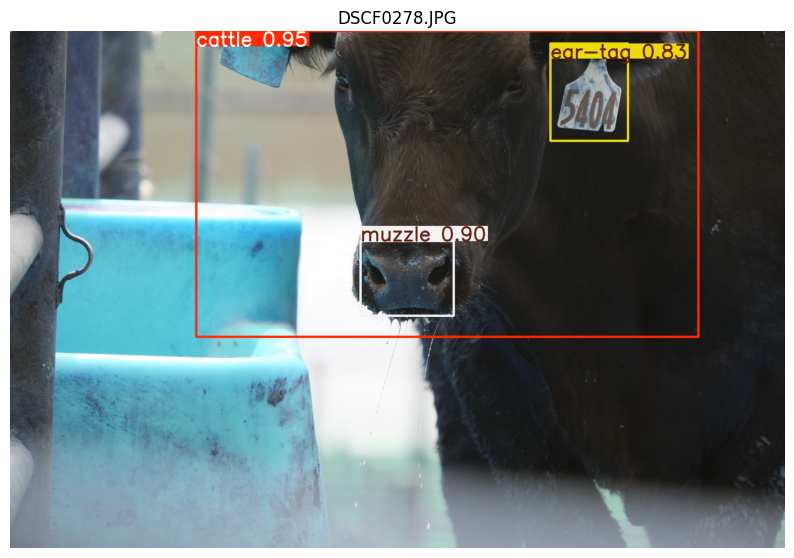


image 1/1 /content/drive/MyDrive/AGST 892/Final Project/Dataset/sorted data/Yolo From json/optionA/test/images/DSCF1566.JPG: 448x640 1 cattle, 1 ear-tag, 1 muzzle, 8.3ms
Speed: 2.8ms preprocess, 8.3ms inference, 1.4ms postprocess per image at shape (1, 3, 448, 640)


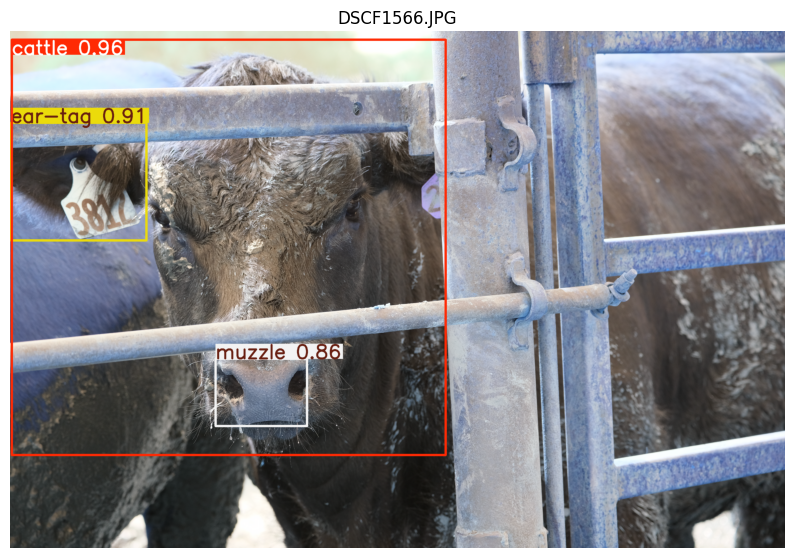


image 1/1 /content/drive/MyDrive/AGST 892/Final Project/Dataset/sorted data/Yolo From json/optionA/test/images/DSCF1301.JPG: 448x640 1 cattle, 1 ear-tag, 1 muzzle, 8.3ms
Speed: 2.8ms preprocess, 8.3ms inference, 1.5ms postprocess per image at shape (1, 3, 448, 640)


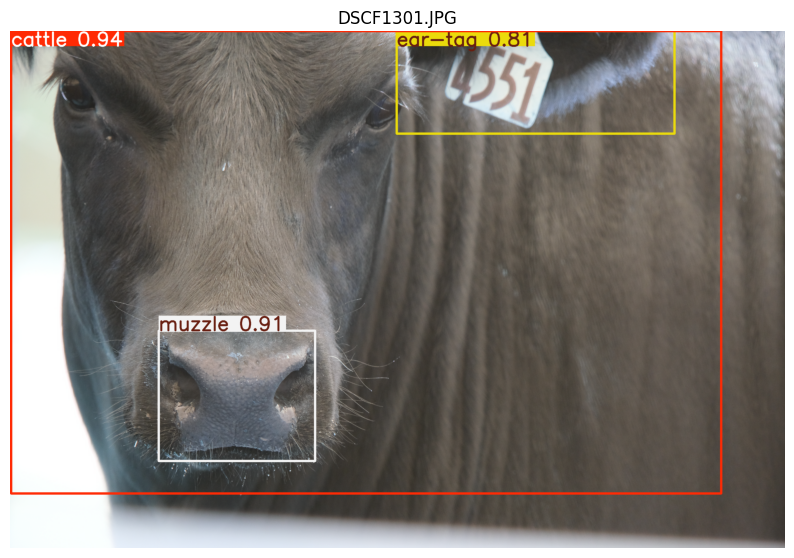


image 1/1 /content/drive/MyDrive/AGST 892/Final Project/Dataset/sorted data/Yolo From json/optionA/test/images/DSCF1167.JPG: 448x640 1 cattle, 1 ear-tag, 1 muzzle, 8.1ms
Speed: 2.7ms preprocess, 8.1ms inference, 1.4ms postprocess per image at shape (1, 3, 448, 640)


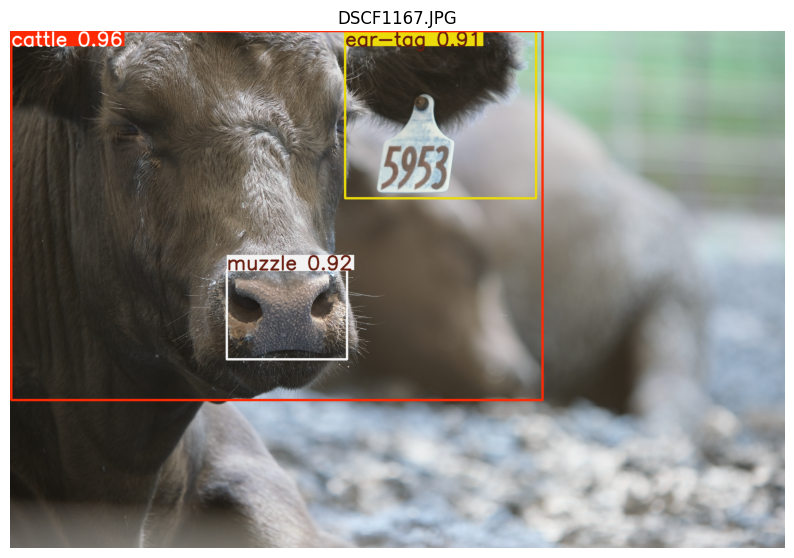


image 1/1 /content/drive/MyDrive/AGST 892/Final Project/Dataset/sorted data/Yolo From json/optionA/test/images/DSCF0752.JPG: 448x640 1 cattle, 1 ear-tag, 1 muzzle, 10.7ms
Speed: 2.9ms preprocess, 10.7ms inference, 1.7ms postprocess per image at shape (1, 3, 448, 640)


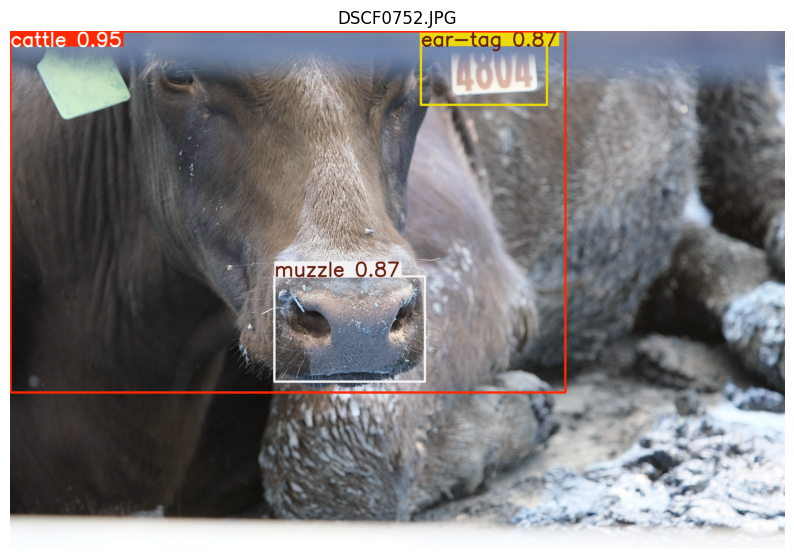


image 1/1 /content/drive/MyDrive/AGST 892/Final Project/Dataset/sorted data/Yolo From json/optionA/test/images/DSCF0586.JPG: 448x640 1 cattle, 1 ear-tag, 1 muzzle, 8.3ms
Speed: 2.7ms preprocess, 8.3ms inference, 1.4ms postprocess per image at shape (1, 3, 448, 640)


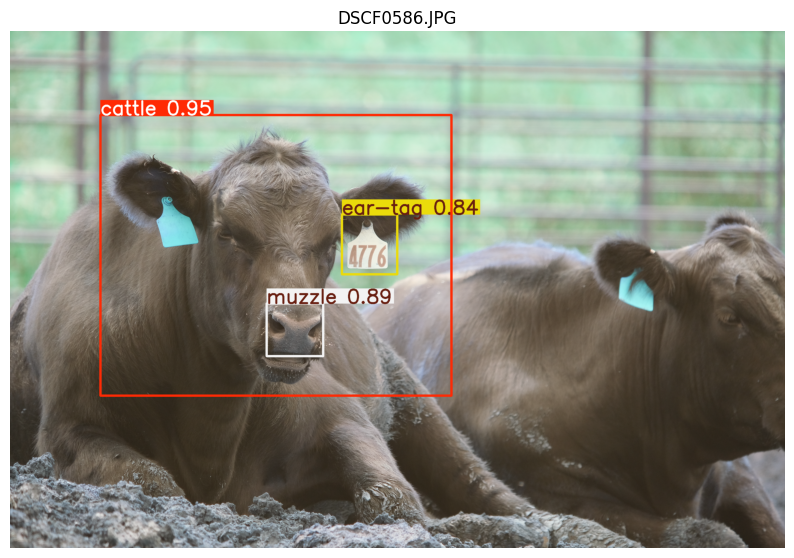

In [ ]:
import glob, random, os
from PIL import Image
import matplotlib.pyplot as plt
import cv2
import numpy as np

# test folder
TEST_IMG_DIR = "/content/drive/MyDrive/AGST 892/Final Project/Dataset/sorted data/Yolo From json/optionA/test/images"
WEIGHTS_PATH = "/content/drive/MyDrive/AGST 892/Final Project/Dataset/sorted data/runs_optionA/y11n_cattle_ear_muzzle_adamw_aug3/weights/best.pt"
# load YOLO model
from ultralytics import YOLO
model = YOLO(WEIGHTS_PATH)   # your trained YOLO model path

# function to show detections
def show_image_with_muzzle_detections(img_path, conf_thres=0.25, imgsz=640):
    results = model(img_path, conf=conf_thres, imgsz=imgsz)[0]
    im = results.plot()  # draws boxes on image
    plt.figure(figsize=(10,10))
    plt.imshow(im)
    plt.axis("off")
    plt.title(os.path.basename(img_path))
    plt.show()

# collect test images
EXTS = ["*.jpg", "*.jpeg", "*.png", "*.JPG", "*.JPEG", "*.PNG"]

img_paths = []
for ext in EXTS:
    img_paths.extend(glob.glob(os.path.join(TEST_IMG_DIR, ext)))

print("Found", len(img_paths), "test images")

# pick some random test images
N = 8
sample_paths = random.sample(img_paths, min(N, len(img_paths)))

# visualize
for p in sample_paths:
    show_image_with_muzzle_detections(p, conf_thres=0.25, imgsz=640)
